In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [2]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


In [3]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [8]:
#Verificar valores Nulos
df.isnull().sum()

,0
total_bill,0
tip,0
sex,0
smoker,0
day,0
time,0
size,0


In [14]:

df.duplicated().sum()

np.int64(0)

In [13]:

df = df.drop_duplicates()

In [12]:

df.columns = df.columns.str.lower().str.replace(" ", "_")
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


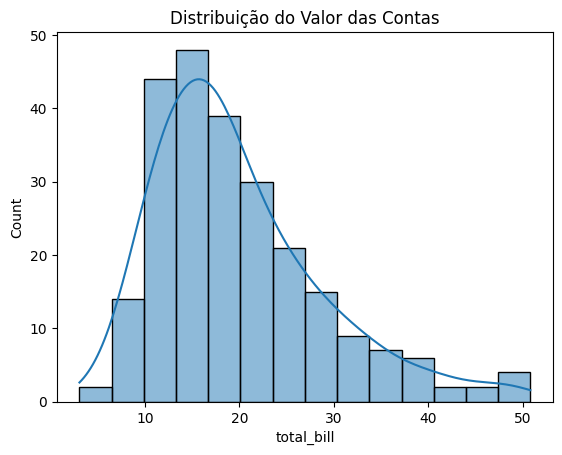

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['total_bill'], kde=True)
plt.title('Distribuição do Valor das Contas')
plt.show()

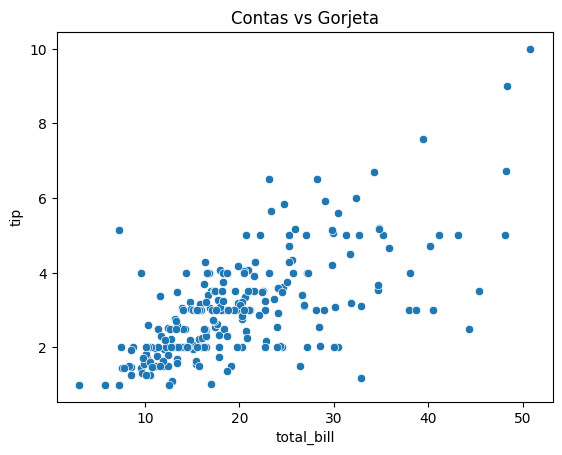

In [17]:
sns.scatterplot(x='total_bill', y='tip', data=df)
plt.title('Contas vs Gorjeta')
plt.show()

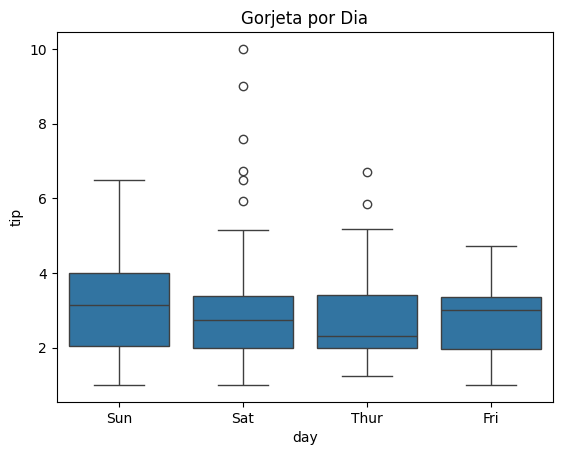

In [18]:
sns.boxplot(x='day', y='tip', data=df)
plt.title('Gorjeta por Dia')
plt.show()

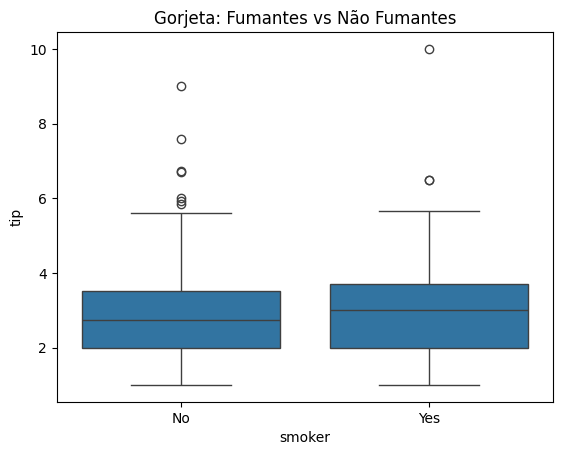

In [19]:
sns.boxplot(x= 'smoker', y='tip', data=df)
plt.title('Gorjeta: Fumantes vs Não Fumantes')
plt.show()

In [20]:
df.groupby('day')['tip'].mean().sort_values(ascending=False)

,tip
day,
Sun,3.255132
Sat,2.993103
Thur,2.784098
Fri,2.734737


In [22]:
df.groupby('smoker')['tip'].mean()

,tip
smoker,
No,2.991854
Yes,3.019674


In [23]:
df['tip_percent'] = (df['tip'] / df['total_bill']) * 100

df[['tip_percent']].describe()

,tip_percent
count,243.000000
mean,16.083121
std,6.119662
min,3.563814
25%,12.883281
50%,15.521855
75%,19.174638
max,71.034483


In [24]:
df.groupby('day')['total_bill'].sum().sort_values(ascending=False)

,total_bill
day,
Sat,1778.40
Sun,1627.16
Thur,1083.33
Fri,325.88


In [25]:
df.groupby('size')['tip'].mean()

,tip
size,
1,1.437500
2,2.586065
3,3.393158
4,4.135405
5,4.028000
6,5.225000


In [26]:
df[['total_bill', 'tip', 'size', 'tip_percent']].corr()

,total_bill,tip,size,tip_percent
total_bill,1.000000,0.674998,0.597589,-0.339400
tip,0.674998,1.000000,0.488400,0.342408
size,0.597589,0.488400,1.000000,-0.143252
tip_percent,-0.339400,0.342408,-0.143252,1.000000


In [27]:
X = df[['total_bill', 'size']]
Y = df['tip']

In [29]:
df_ml = df[['total_bill', 'size', 'smoker', 'day', 'tip']]
df_ml.head()

,total_bill,size,smoker,day,tip
0,16.99,2,No,Sun,1.01
1,10.34,3,No,Sun,1.66
2,21.01,3,No,Sun,3.50
3,23.68,2,No,Sun,3.31
4,24.59,4,No,Sun,3.61


In [30]:
df_ml = pd.get_dummies(df_ml, drop_first=True)
df_ml.head()

,total_bill,size,tip,smoker_Yes,day_Sat,day_Sun,day_Thur
0,16.99,2,1.01,False,False,True,False
1,10.34,3,1.66,False,False,True,False
2,21.01,3,3.50,False,False,True,False
3,23.68,2,3.31,False,False,True,False
4,24.59,4,3.61,False,False,True,False


In [31]:
X = df_ml.drop('tip', axis=1)
Y = df_ml['tip']

In [36]:
from sklearn.model_selection import train_test_split

# Corrigido: 'y' alterado para 'Y' para coincidir com a variável definida anteriormente
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [38]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [39]:
y_pred = model.predict(X_test)

In [41]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Erro médio (MAE):", mae)
print("R2", r2)

Erro médio (MAE): 0.7635777534626428
R2 0.5216849590559192


In [44]:
coef = pd.DataFrame(model.coef_, X.columns, columns=['Coeficiente'])
coef.sort_values(by='Coeficiente', ascending=False)

,Coeficiente
size,0.214259
day_Sun,0.094761
total_bill,0.084981
day_Thur,0.063090
day_Sat,0.027444
smoker_Yes,-0.046194


In [45]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_tree))
print("R2:", r2_score(y_test, y_pred_tree))

MAE: 0.8479591836734693
R2: 0.49128834122174103


In [47]:
df.to_csv('dados_tratados.csv', index=False)